# Logistic Regression

`Logistic regression` is a `classification` algorithm used to assign observations to a discrete set of classes. 
Unlike linear regression which outputs continuous number values, logistic regression transforms its output using the `logistic sigmoid function` to return a `probability value` which can then be mapped to two or more discrete classes.

Logistic regression can be used for:
1. Binary Classification
2. Multi-class Classification
3. One-vs-Rest Classification

## Assumptions of Logistic regression
1. The dependent variable must be categorical in nature.
2. The independent variables(features) must be independent.
3. There should be no outliers in the data. Check for outliers.
4. There should be no high correlations among the independent variables. This can be checked using a correlation matrix.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

In [2]:
# data import
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
# pre prcoess the data
# remove the deck column
df.drop('deck', axis=1)
# impute missing values in age and fare
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
# impute missing values in embark and embarked town
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# encode the categorical variables using for loop where object and categoy datatypes are given
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = LabelEncoder().fit_transform(df[col])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,2,man,True,7,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,0,woman,False,2,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,2,woman,False,7,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,0,woman,False,2,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,2,man,True,7,Southampton,no,True


In [17]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,2,man,True,7,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,0,woman,False,2,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,2,woman,False,7,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,0,woman,False,2,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,2,man,True,7,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,1,man,True,7,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,0,woman,False,1,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,2,woman,False,7,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,0,man,True,2,Cherbourg,yes,True


In [5]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [6]:
# 3. Separate features (X) and target (y)
# 'alive' is dropped because it is a duplicate text version of 'survived'
X = df.drop(columns=['survived', 'alive']) 
y = df['survived']

In [20]:
X

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,3,male,22.0,1,0,7.2500,S,2,man,True,7,Southampton,False
1,1,female,38.0,1,0,71.2833,C,0,woman,False,2,Cherbourg,False
2,3,female,26.0,0,0,7.9250,S,2,woman,False,7,Southampton,True
3,1,female,35.0,1,0,53.1000,S,0,woman,False,2,Southampton,False
4,3,male,35.0,0,0,8.0500,S,2,man,True,7,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,1,man,True,7,Southampton,True
887,1,female,19.0,0,0,30.0000,S,0,woman,False,1,Southampton,True
888,3,female,28.0,1,2,23.4500,S,2,woman,False,7,Southampton,False
889,1,male,26.0,0,0,30.0000,C,0,man,True,2,Cherbourg,True


In [21]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [7]:
# 4. One-Hot Encode categorical variables safely
X = pd.get_dummies(X, drop_first=True)

In [8]:
X

,pclass,age,sibsp,parch,fare,class,adult_male,deck,alone,sex_male,embarked_Q,embarked_S,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton
0,3,22.0,1,0,7.2500,2,True,7,False,True,False,True,True,False,False,True
1,1,38.0,1,0,71.2833,0,False,2,False,False,False,False,False,True,False,False
2,3,26.0,0,0,7.9250,2,False,7,True,False,False,True,False,True,False,True
3,1,35.0,1,0,53.1000,0,False,2,False,False,False,True,False,True,False,True
4,3,35.0,0,0,8.0500,2,True,7,True,True,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,True,7,True,True,False,True,True,False,False,True
887,1,19.0,0,0,30.0000,0,False,1,True,False,False,True,False,True,False,True
888,3,28.0,1,2,23.4500,2,False,7,False,False,False,True,False,True,False,True
889,1,26.0,0,0,30.0000,0,True,2,True,True,False,False,True,False,False,False


In [9]:
# train test split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
# model call
model = LogisticRegression()

In [11]:
# train the model
model.fit(X_train, y_train)

c:\Users\Hair\AppData\Local\miniconda3\envs\python_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
# predict the values
y_pred = model.predict(X_test)

In [13]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0])

## Accuracy Score
**What is Good?**
- Balanced Data: (85\%) or higher is generally considered good for standard datasets 
- Imbalanced Data: A high accuracy value can be misleading. If (95%) of your data belongs to Class 0, an accuracy of (0.95) is actually a bad model because it might just be guessing Class 0 every time.
- Red Flag: Exactly (1.0 (100\%) usually means your model has overfitted (memorized the training data) or you have a data leakage issue.
## Recall Score (Sensitivity)
- Perfect: 1.0 (100%)
- What is Good? 
0.80 (80%) to 0.99 (99%) depending on the stakes.For medical diagnoses (like cancer screening) or fraud detection, a good model must have a recall of 0.95 (95%) or higher because missing a positive case (False Negative) has terrible consequences.
- Red Flag: A recall of (1.0) is easy to achieve by simply predicting "Positive" for every single row, but it makes the model useless because Precision will drop significantly.

## F1 Score
Because the F1 Score balances both Precision and Recall, it is the most reliable single metric for a good model—especially on real-world, imbalanced data.
- Perfect: 1.0 (100%)
- What is Good?
  - Excellent: (0.90) to (0.99) (Rare and highly optimal).
  - Good / Acceptable: (0.70) to (0.89) (Standard for most business and engineering applications).
  - Poor: Below (0.60) (The model is struggling to correctly balance false alarms and missed cases).

In [14]:
# evaluate the model
print('Accuracy Score: ', accuracy_score(y_test, y_pred))
print('Recall Score: ', recall_score(y_test, y_pred))
print('Precision Score: ', precision_score(y_test, y_pred))
print('F1 Score: ', f1_score(y_test, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred))
print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy Score:  0.7877094972067039
Recall Score:  0.6901408450704225
Precision Score:  0.7538461538461538
F1 Score:  0.7205882352941176
Confusion Matrix: 
 [[92 16]
 [22 49]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       108
           1       0.75      0.69      0.72        71

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



- Accuracy score = (TP + TN)/(TP + TN + FP + FN)
- Precision score = (TP)/(TP+FP)
- Recall score = TP/(TP + FN)
- F1_score = 2 * Recall * Precision/Recall + Precision



## The Confusion Matrix
A Confusion Matrix is a tabular summary of your model's correct and incorrect predictions. It breaks results down into four categories:
- True Positive (TP): Model predicted Yes, Actual was Yes. (Correct)
- True Negative (TN): Model predicted No, Actual was No. (Correct)
- False Positive (FP): Model predicted Yes, Actual was No. (Type I Error / False Alarm)
- False Negative (FN): Model predicted No, Actual was Yes. (Type II Error / Missed)

| | Predict No | Precdicted Yes |
| :---: | :--- | :---: |
| Actual No | TN | FP |
| Actual Yes| FN| TP |



In [ ]:
(49+92)/(92+49+22+16)  # Accuracy score = (TP + TN)/(TP + TN + FP + FN)


0.6901408450704225

In [19]:
49/(49+16)  # Precision score = TP/(TP + FP)

0.7538461538461538

In [20]:
49/(49+22)  # Recall score = TP/(TP + FN)

0.6901408450704225

In [ ]:
2*(0.7538461538461538*0.6904761904761905)/(0.7538461538461538+0.6904761904761905) 
 # F1 score = 2*(Precision * Recall)/(Precision + Recall)

0.720770986558458

## confusion matrix
A good model should have high numbers on the main diagonal (top-left and bottom-right) and low numbers on the off-diagonal (top-right and bottom-left)

Text(95.72222222222221, 0.5, 'Actual')

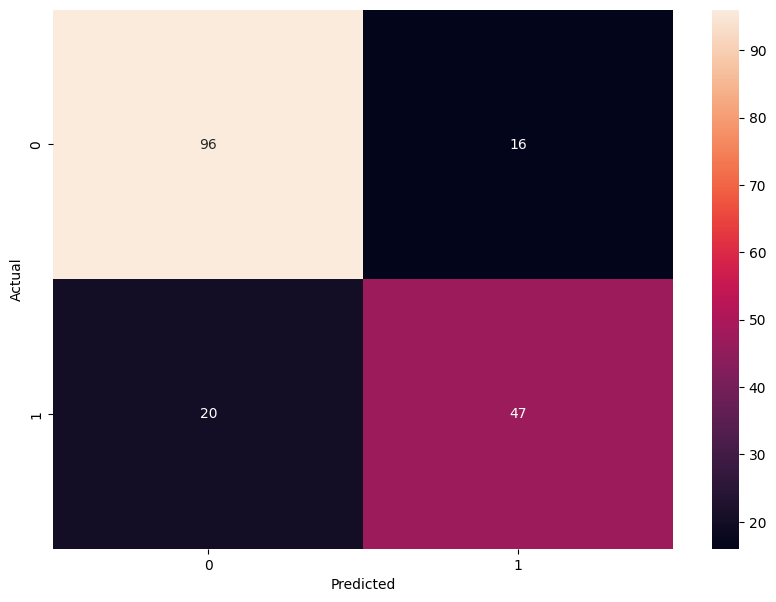

In [30]:
# plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [22]:
# save the model
import pickle
pickle.dump(model, open('./saved_models/02_model_logistic_regression.pkl', 'wb'))

In [25]:
import pickle

# Define the correct relative path to your saved pickle file
file_path = 'saved_models/02_model_logistic_regression.pkl'

# Load the model back into Python
with open(file_path, 'rb') as file:
    loaded_model = pickle.load(file)

print("Model successfully loaded!")
print(loaded_model)


Model successfully loaded!
LogisticRegression()
